In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00


In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="eYOhxiS5OKSg54UHPxqR")
project = rf.workspace("alejandros-workspace-msiww").project("football-player-detection-gjrld")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-player-detection-1 in yolov8:: 100%|██████████| 347/347 [00:00<00:00, 8386.43it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
import os

# Vemos la estructura que ha creado Roboflow
dataset_path = dataset.location
print(f"Dataset guardado en: {dataset_path}")
print(f"\nContenido:")
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(f"  {folder}/: {len(files)} archivos")

Dataset guardado en: /content/football-player-detection-1

Contenido:
  test/: 2 archivos
  train/: 2 archivos
  valid/: 2 archivos


In [9]:
# Vemos el contenido detallado de cada carpeta
for folder in ["train", "valid", "test"]:
    folder_path = os.path.join(dataset_path, folder)
    for subfolder in os.listdir(folder_path):
        subfolder_path = os.path.join(folder_path, subfolder)
        if os.path.isdir(subfolder_path):
            count = len(os.listdir(subfolder_path))
            print(f"  {folder}/{subfolder}/: {count} archivos")

  train/labels/: 150 archivos
  train/images/: 150 archivos
  valid/labels/: 14 archivos
  valid/images/: 14 archivos
  test/labels/: 7 archivos
  test/images/: 7 archivos


In [10]:
from ultralytics import YOLO

# Cargamos YOLOv8 nano, el modelo más pequeño y rápido
# Es perfecto para empezar y para GPUs pequeñas
model = YOLO("yolov8n.pt")

# Entrenamos el modelo con nuestro dataset
results = model.train(
    data=f"{dataset_path}/data.yaml",
    epochs=50,
    imgsz=512,
    batch=16,
    name="football_player_v1",
    patience=10,
    device=0
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-player-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=football_player_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

In [11]:
import shutil

# Copiamos el mejor modelo a tu Google Drive
shutil.copy(
    '/content/runs/detect/football_player_v1/weights/best.pt',
    '/content/drive/MyDrive/tactical-football-vision-data/best_v1.pt'
)
print("Modelo guardado en Drive")

Modelo guardado en Drive


In [12]:
from google.colab import files
files.download('/content/drive/MyDrive/tactical-football-vision-data/best_v1.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from ultralytics import YOLO
import cv2

# Cargamos el modelo entrenado
model = YOLO('/content/drive/MyDrive/tactical-football-vision-data/best_v1.pt')

# Hacemos inferencia en una imagen de prueba
results = model.predict(
    source='/content/football-player-detection-1/test/images',
    conf=0.3,
    save=True,
    name='test_predictions'
)

print(f"Predicciones guardadas en: {results[0].save_dir}")


image 1/7 /content/football-player-detection-1/test/images/frame_00023_jpg.rf.5a51c3e0224b6df5d02a5f4f967ddb39.jpg: 512x512 19 players, 20.4ms
image 2/7 /content/football-player-detection-1/test/images/frame_00027_jpg.rf.f271f0cbe19c36a526b7eddb7a77d6db.jpg: 512x512 21 players, 10.7ms
image 3/7 /content/football-player-detection-1/test/images/frame_00035_jpg.rf.bedb47abe8dc10f0231c7b28c658362f.jpg: 512x512 26 players, 36.6ms
image 4/7 /content/football-player-detection-1/test/images/frame_00069_jpg.rf.a10904131b5ab8bbf5a43c21f0bdcf5d.jpg: 512x512 22 players, 11.4ms
image 5/7 /content/football-player-detection-1/test/images/frame_00144_jpg.rf.e23e55f24c6fc3a538944be044159425.jpg: 512x512 13 players, 8.9ms
image 6/7 /content/football-player-detection-1/test/images/frame_00146_jpg.rf.6c77ee066467336c650575cf6f580fc2.jpg: 512x512 15 players, 17.3ms
image 7/7 /content/football-player-detection-1/test/images/frame_00154_jpg.rf.4a76af408f389cd00e3e79e9a45773ae.jpg: 512x512 18 players, 22.6ms

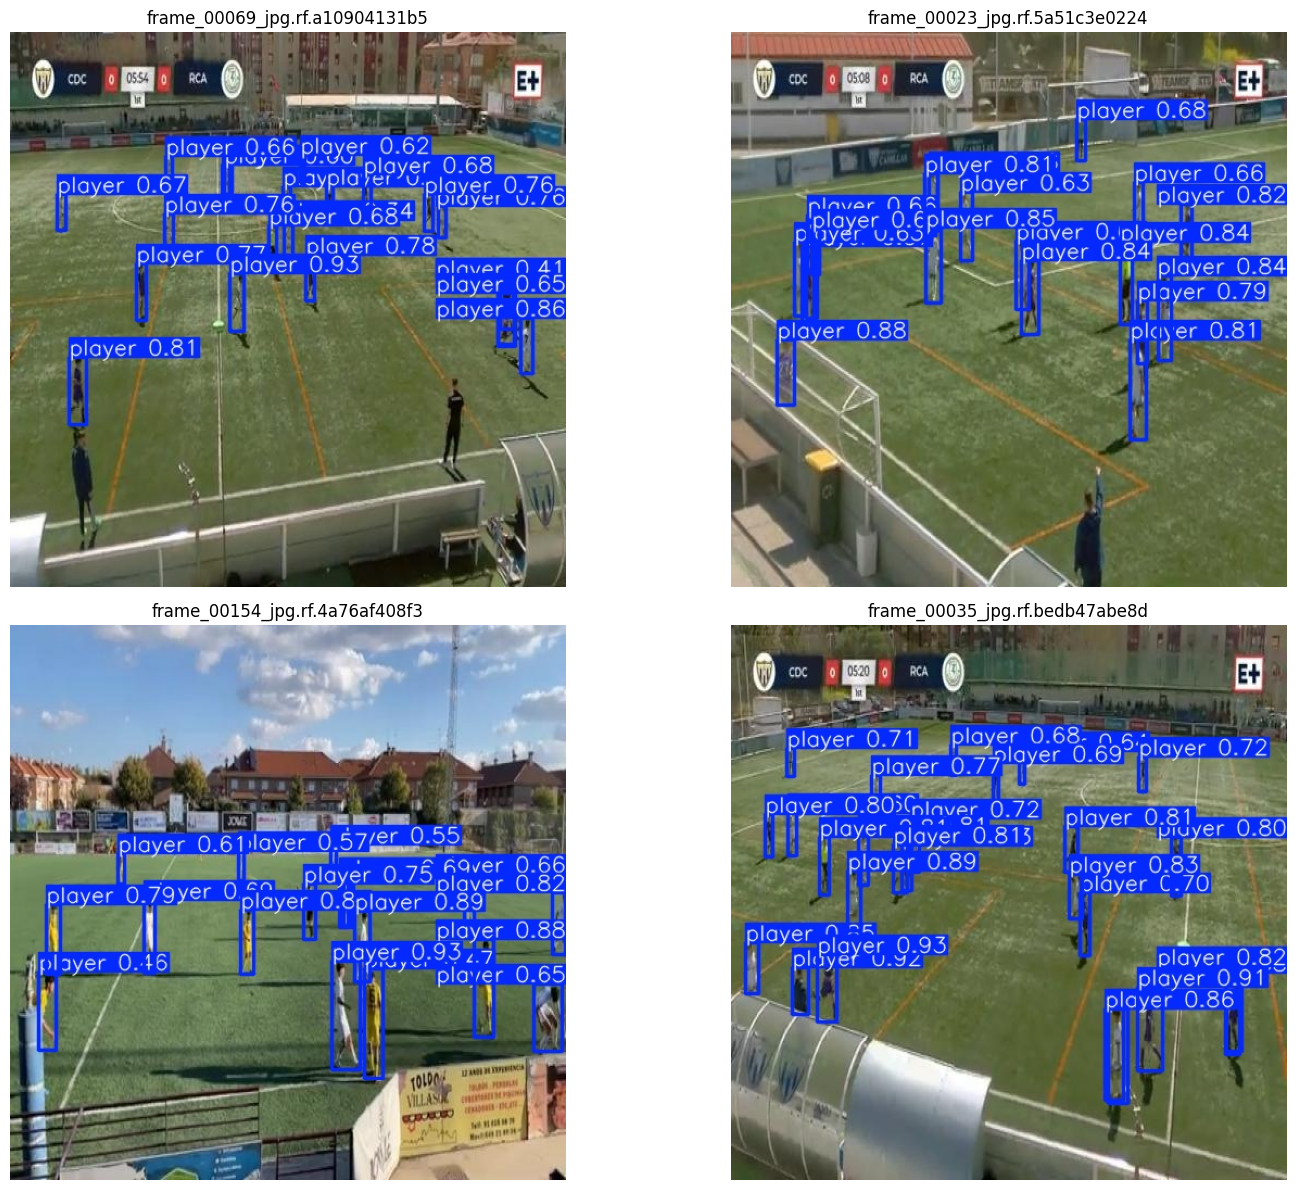

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Carpeta donde se guardaron las predicciones
pred_dir = '/content/runs/detect/test_predictions'

# Listamos las imágenes generadas
images = [f for f in os.listdir(pred_dir) if f.endswith('.jpg')]

# Mostramos las primeras 4
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, img_name in enumerate(images[:4]):
    img_path = os.path.join(pred_dir, img_name)
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(img_name[:30])

plt.tight_layout()
plt.show()